* Loader (before model, makes Normalizer input):
    * mean, std
    * log1p(mean), log1p(std)
    * theta (NB MoM)

* Normalizer (part of model, makes Encoder input):
    * Raw: return x

    * logVST: return log_x = log(x)
    
    * zlogVST: return z_log_x = (log_x - log_mean)/log_std
        * log_mean and log_std are fixed from Loader (or learnable?)

    * NBVST: return nb_x = (x - mean)/theta
        * mean and theta are fixed from Loader (or learnable?)

    * zNBVST: return z_nb_x = (nb_x - mean(nb_x))/std(nb_x)
        * mean and theta are fixed from Loader (or learnable?)

    * LFC: return lfc = log(x) - log_mean
        * mean and theta are learnable via NBLoss, initialized from loader
    
    * zLFC: return z_lfc = (lfc - mean(lfc))/std(lfc)
        * mean and theta are learnable via NBLoss, initialized from loader

* Loss function
    * MSE/MAE:
        * reconstruction
        * on log_x, nb_x, z_log_x, z_nb_x
        * e.g. logVST, zlogVST, NBVST, zNBVST

    * CE:
        * classification
        * any (performed on y labels)

    * NB: 
        * in combination with MSE/MAE/CE (and/or standalone reconstruction?)
        * on x, mean (learnable), theta (learnable)
        * e.g. raw, LFC, zLFC

In [1]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 79361)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)

# #### Device() ####
# device = cuda:1

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:1)
# edge_attr                (32464, 16)              Tensor (cuda:1)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:1)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

In [2]:
_batch.x.shape

torch.Size([279872, 1])

In [3]:
dataset[0].num_node_features

1

In [4]:
b = _batch.x.reshape(-1, dataset[0].num_nodes, dataset[0].num_node_features)

In [5]:
(b==0).sum(dim=0).shape

torch.Size([4373, 1])

In [6]:
b.dim()

3

In [7]:
from modules.layers import MultiheadSetPooling
from modules.model import Dims, Encoder, Latent, BaseAutoencoder
from modules.norm import LogCounts, NBVST
from modules.train import Loader
from modules.utils import dict_summary
import torch
import torch.nn as nn

In [8]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

dims = Dims(
    dataset=dataset,
    embed_dim=64,
    num_heads=4,
    method='set'
)

enc = Encoder(
    dims=dims,
    method='set',

    norm_class=NBVST,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

lat = Latent(
    dims=dims,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

enc.init_with_loader(loader)

out = enc(_batch, need_weights=True)
out = lat(out, need_weights=True)

print(out.keys())

dict_keys(['x', 'x_t', 'layer_outs', 'h_node', 'h_pool', 'z'])


In [9]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

ae = BaseAutoencoder(
    dataset=dataset,
    embed_dim=64,
    num_heads=4,
    method='set',

    norm_class=NBVST,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

ae.init_with_loader(loader)

out = ae(_batch, need_weights=True)
# out = ae(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)

# x_t                      (279872, 1)              Tensor (cuda:1)
# layer_outs               4                        dict
# h_node                   (64, 4373, 64)           Tensor (cuda:1)
# h_pool                   (64, 305, 64)            Tensor (cuda:1)
# z                        (64, 64)                 Tensor (cuda:1)
# x_preds                  (279872, 1)              Tensor (cuda:1)



---

In [10]:
from modules.trainers import ReconstrTrainer
from modules.norm import RawCounts, LogCounts, NBVST


In [44]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

trainer = ReconstrTrainer(1e-4, norm_class=LogCounts)

ae = BaseAutoencoder(
    dataset=dataset,
    embed_dim=128,
    num_heads=4,
    method='set',

    norm_class=LogCounts,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',

    norm_kwargs={'libnorm':True, 'znorm':True, 'learnable':True}
)

trainer.run(
    model=ae,
    loader=loader,
    num_epochs=50,
    report_metrics=['loss','rmse','mae','r2'],
    verbose=True
)

  0%|          | 0/50 [00:00<?, ?it/s]

Test	 loss=0.8395    rmse=0.8220    mae=0.5521    r2=0.8260



In [12]:
loader.stats

{'theta': tensor([[1.5292],
         [2.1165],
         [1.5054],
         ...,
         [1.0643],
         [1.7693],
         [0.9130]], device='cuda:1'),
 'pi': tensor([[0.0000e+00],
         [0.0000e+00],
         [0.0000e+00],
         ...,
         [6.5457e-05],
         [0.0000e+00],
         [1.4086e-01]], device='cuda:1'),
 'class_counts': tensor([149,  56, 388, 149,  80], device='cuda:1'),
 'lib_median': tensor(20358666., device='cuda:1')}

In [13]:
# trainer = ReconstrTrainer(1e-4, norm_class=LogCounts)

# ae2 = BaseAutoencoder(
#     dataset=dataset,
#     embed_dim=64,
#     num_heads=4,
#     method='node',

#     norm_class=NBVST,
#     encoder_class=nn.Linear,
#     pooling_class=MultiheadSetPooling,

#     hidden_dims=2,
#     act_fn=nn.ReLU,
#     norm_fn='layer',
# )

# trainer.run(
#     model=ae2,
#     loader=loader,
#     num_epochs=50,
#     report_metrics=['loss','rmse','mae','r2'],
#     verbose=True
# )

In [14]:
trainer.model.encoder.norm.pi.unique()

tensor([0.0000e+00, 2.5125e-11, 3.1399e-11,  ..., 6.6655e-01, 7.4693e-01,
        8.2641e-01], device='cuda:1', grad_fn=<Unique2Backward0>)

---

In [15]:
def tensor_summary(x):
    items = {
        'mean': x.mean(),
        'std':x.std(), 
        'min': x.min(), 
        'Q1': x.quantile(0.25), 
        'median': x.quantile(0.50), 
        'Q3': x.quantile(0.75), 
        'P99': x.quantile(0.99),
        'max': x.max()
    }
    for k,v in items.items():
        print(f'{k}: {v:.5}')

In [16]:
b = _batch.x.reshape(-1, dataset[0].num_nodes, dataset[0].num_node_features).to(torch.float32)

In [17]:
b[:,:,0].sum(dim=1).shape

torch.Size([64])

In [18]:
b.sum(dim=(1,2)).median().item()

20240880.0

In [19]:
b.sum(dim=1).shape

torch.Size([64, 1])

In [20]:
libsize = b.sum(dim=1, keepdim=True).to(torch.float32)

In [21]:
r = b/libsize

In [22]:
tensor_summary(b)

mean: 4673.9
std: 1.76e+04
min: 0.0
Q1: 377.0
median: 1442.0
Q3: 4020.0
P99: 5.1743e+04
max: 9.7122e+05


In [23]:
tensor_summary(libsize)

mean: 2.0439e+07
std: 5.2633e+06
min: 6.1953e+06
Q1: 1.7402e+07
median: 2.06e+07
Q3: 2.4068e+07
P99: 3.2591e+07
max: 3.557e+07


In [24]:
tensor_summary(r)

mean: 0.00022868
std: 0.00082708
min: 0.0
Q1: 1.9623e-05
median: 7.3792e-05
Q3: 0.00020044
P99: 0.0024892
max: 0.043837


In [25]:
tensor_summary(r*libsize.median())

mean: 4628.6
std: 1.6741e+04
min: 0.0
Q1: 397.18
median: 1493.6
Q3: 4057.0
P99: 5.0383e+04
max: 8.8729e+05


In [26]:
tensor_summary(r*libsize.min())

mean: 1416.7
std: 5124.0
min: 0.0
Q1: 121.57
median: 457.17
Q3: 1241.8
P99: 1.5421e+04
max: 2.7158e+05


---

In [27]:
import seaborn as sns
from modules.math import nb_theta, nbvst_transform, z_transform

In [28]:
def hist_kde(x):
    x = x.view(-1).cpu()
    sns.displot(x, kde=True)

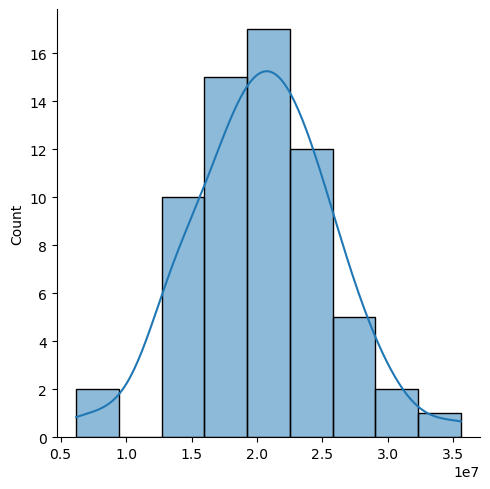

In [29]:
hist_kde(libsize) # norm dist? some right skew, too few to tell

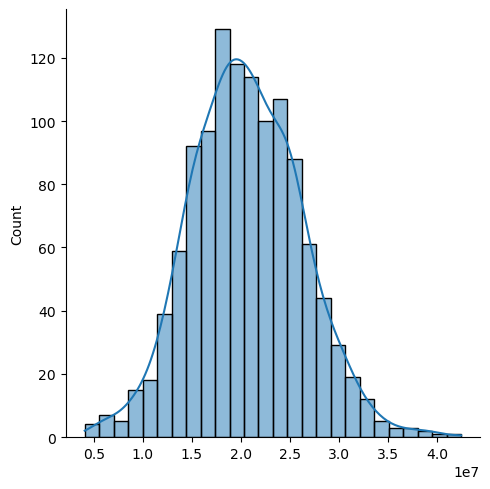

In [30]:
tot_libsize = dataset.x.sum(dim=1, keepdim=True).to(torch.float32)
hist_kde(tot_libsize) # total BRCA, libsize looks norm dist.

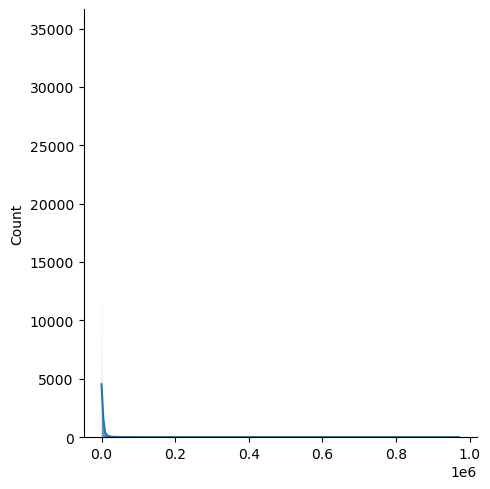

In [31]:
hist_kde(b) # heavy right skew

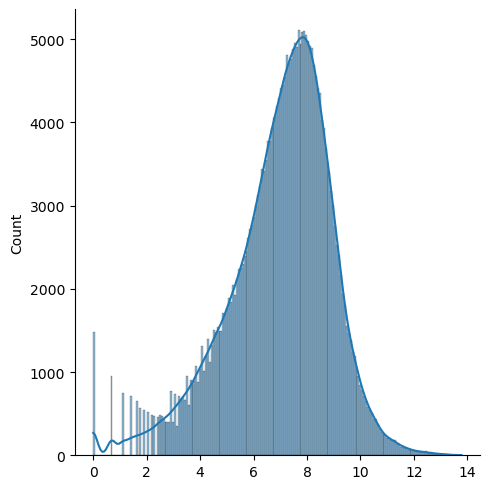

In [32]:
hist_kde(b.log1p()) # more norm; non-smooth left tail

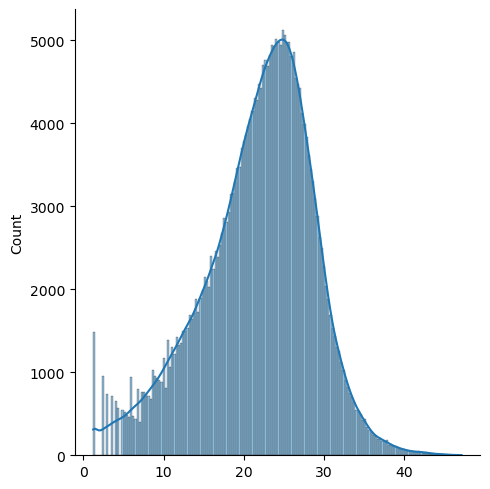

In [33]:
b_theta = nb_theta(b.mean(), b.var())
b_nb = nbvst_transform(b, b_theta)
hist_kde(b_nb) # similar to log1p(b)

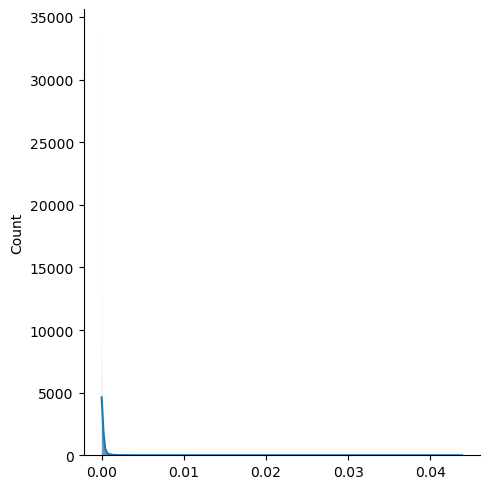

In [34]:
hist_kde(r) # heavy right skew, similar to b

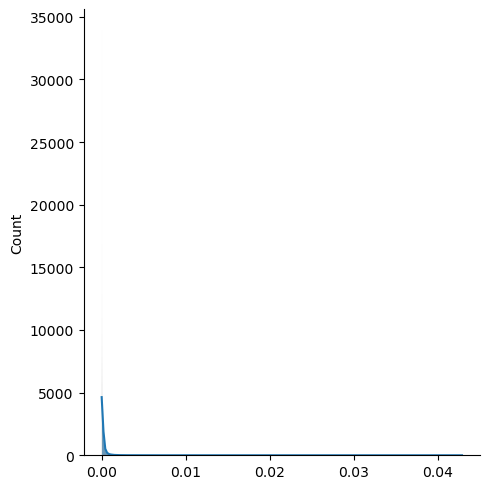

In [35]:
hist_kde(r.log1p()) # still heavy right skew

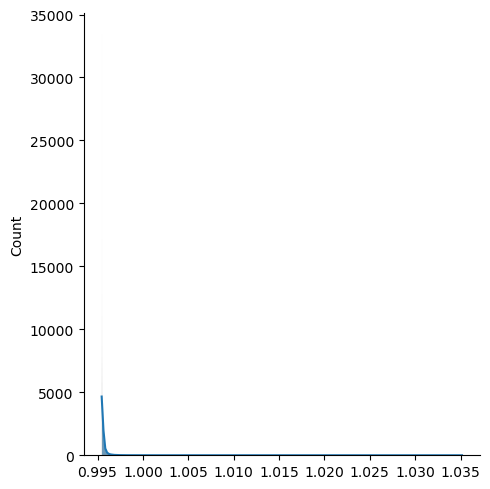

In [36]:
r_theta = nb_theta(r.mean(), r.var())
r_nb = nbvst_transform(r, r_theta)
hist_kde(r_nb) # similar to log1p

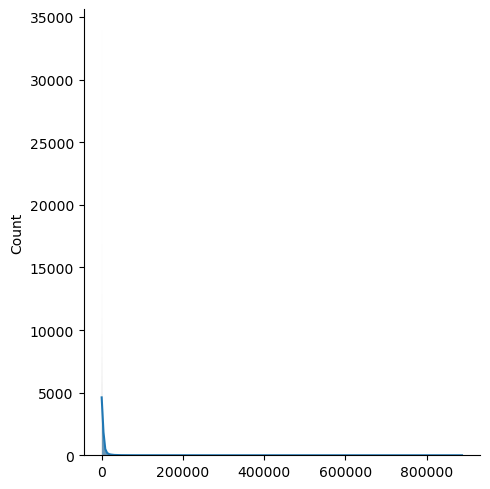

In [37]:
rmed = r*libsize.median()
hist_kde(rmed) # heavy right skew, similar to b

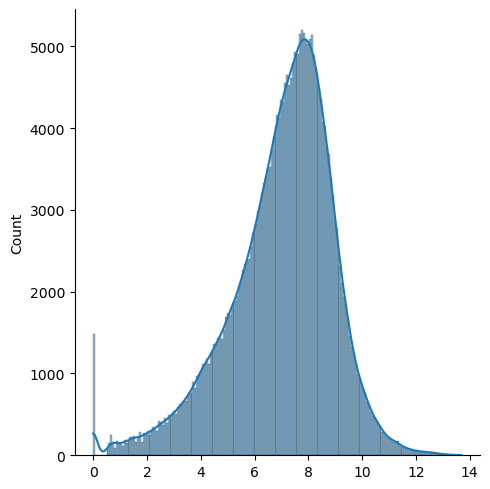

In [38]:
hist_kde(rmed.log1p()) # smooth tail

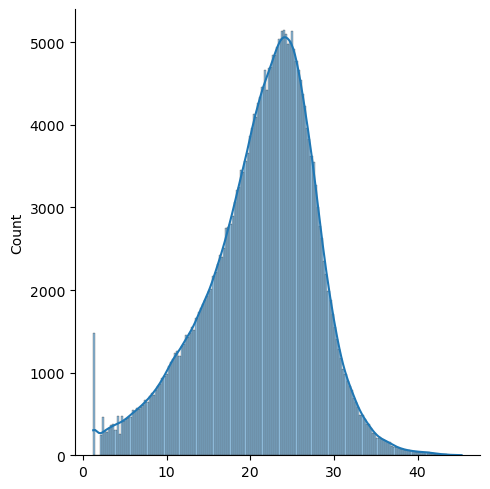

In [39]:
rmed_theta = nb_theta(rmed.mean(), rmed.var())
rmed_nb = nbvst_transform(rmed, rmed_theta)
hist_kde(rmed_nb) # similar to log1p

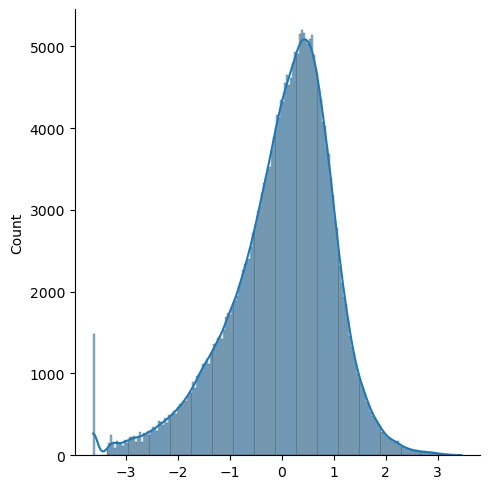

In [40]:
zrmed_log = z_transform(rmed.log1p(), rmed.log1p().mean(), rmed.log1p().std())
hist_kde(zrmed_log)

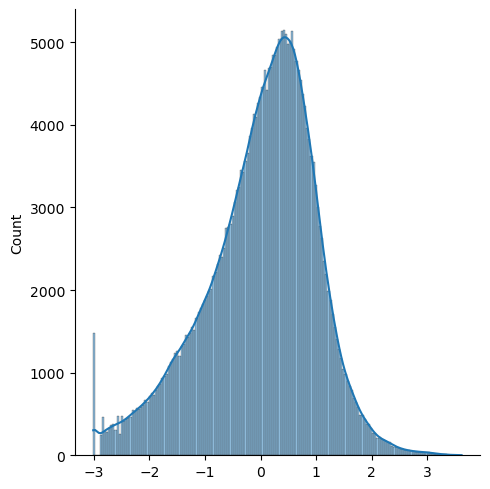

In [41]:
zrmed_nb = z_transform(rmed_nb, rmed_nb.mean(), rmed_nb.std())
hist_kde(zrmed_nb) # does not change shape of graph, just reshapes to have mean ~ 0, std = 1

In [42]:
tensor_summary(zrmed_nb)

mean: -1.0599e-07
std: 1.0
min: -3.0116
Q1: -0.57373
median: 0.14027
Q3: 0.68249
P99: 2.0526
max: 3.6136


In [43]:
# geommean works too?